In [5]:
pip install sktime

Note: you may need to restart the kernel to use updated packages.


In [6]:
!pip install optuna scipy -q

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc
import optuna
from scipy.stats import skew, kurtosis
from sklearn.linear_model import RidgeClassifierCV, RidgeClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sktime.transformations.panel.rocket import MiniRocketMultivariate

In [8]:
# ==========================================
# 1. CARREGAMENTO DOS DADOS
# ==========================================
print("1. Carregando Opportunity...")
data_path = "/kaggle/input/datasets/lscolombo/opportunity/opportunity_v2.npz"
dados = np.load(data_path)

# Eixos: (Amostras, Canais, Tempo)
X_train = np.transpose(dados['X_train'], (0, 2, 1)).astype(np.float32)
X_val   = np.transpose(dados['X_val'], (0, 2, 1)).astype(np.float32)
X_test  = np.transpose(dados['X_test'], (0, 2, 1)).astype(np.float32)
y_train = dados['y_train']
y_val   = dados['y_val']
y_test  = dados['y_test']

del dados
gc.collect()

resultados = {}

def avaliar(cenario, clf, X_v, y_v, X_t, y_t):
    print(f"\n{'='*60}\nAVALIANDO: {cenario}\n{'='*60}")
    p_v = clf.predict(X_v)
    p_t = clf.predict(X_t)

    f1_v = f1_score(y_v, p_v, average='macro')
    f1_t = f1_score(y_t, p_t, average='macro')
    acc_t = accuracy_score(y_t, p_t)

    print(f"F1-Macro Validação: {f1_v:.4f}")
    print(f"F1-Macro Teste:     {f1_t:.4f}")
    print(f"Acurácia Teste:     {acc_t:.4f}")

    print("\n--- Relatório Detalhado (Teste) ---")
    print(classification_report(y_t, p_t))

    # Matriz de confusão normalizada
    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(y_t, p_t, cmap='YlGnBu', ax=ax, normalize='true')
    plt.title(f"Matriz de Confusão Normalizada - {cenario}")
    plt.show()

    # Salvando resultados para o resumo
    resultados[cenario] = {'F1-Macro': f1_t, 'Acurácia': acc_t}

1. Carregando Opportunity...



>>> PREPARANDO MATRIZES EM ESCALA GLOBAL (Evitando recálculo)
1. Extraindo features convolucionais com MiniRocket...
2. Escalonando matrizes do MiniRocket...
3. Extraindo features estatísticas...
4. Concatenando e escalonando matrizes combinadas (Cenários 3 e 4)...
>>> PREPARAÇÃO CONCLUÍDA COM SUCESSO!

>>> CENÁRIO 1: Apenas MiniRocket, Sem Optuna

AVALIANDO: C1 (Apenas MiniRocket, Sem Optuna)
F1-Macro Validação: 0.4024
F1-Macro Teste:     0.4527
Acurácia Teste:     0.7711

--- Relatório Detalhado (Teste) ---
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      3815
           1       0.35      0.64      0.45        61
           2       0.39      0.63      0.48        46
           3       0.23      0.24      0.24        37
           4       0.58      0.55      0.56        82
           5       0.68      0.73      0.70        73
           6       0.24      0.16      0.19        38
           7       0.54      0.45      0.49       1

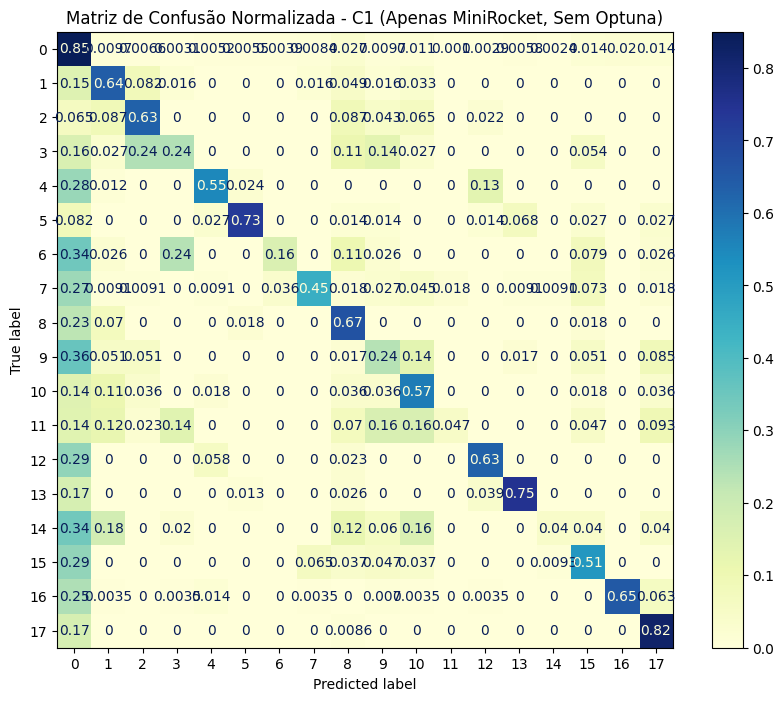

In [12]:
# ==========================================
# PREPARAÇÃO OTIMIZADA DE DADOS E FEATURES
# ==========================================
print("\n>>> PREPARANDO MATRIZES EM ESCALA GLOBAL (Evitando recálculo)")

# 0. Definição dos índices (caso não estejam na célula anterior)
IDX_WEARABLE = slice(0, 133)
IDX_AMBIENTE = slice(133, 242)

# 1. Extração de Features com MiniRocket (A ETAPA QUE FALTAVA)
print("1. Extraindo features convolucionais com MiniRocket...")
minirocket = MiniRocketMultivariate()
minirocket.fit(X_train[:, IDX_WEARABLE, :])

def transform_in_batches(model, X, batch_size=2000):
    n_samples = X.shape[0]
    features = []
    for i in range(0, n_samples, batch_size):
        fim = min(i + batch_size, n_samples)
        features.append(model.transform(X[i:fim, IDX_WEARABLE, :]).astype(np.float32))
    return np.vstack(features)

X_train_mr = transform_in_batches(minirocket, X_train)
X_val_mr   = transform_in_batches(minirocket, X_val)
X_test_mr  = transform_in_batches(minirocket, X_test)

# 2. Escalonamento ÚNICO para features MiniRocket (Cenários 1 e 2)
print("2. Escalonando matrizes do MiniRocket...")
scaler_mr = StandardScaler()
X_train_mr_scaled = scaler_mr.fit_transform(X_train_mr)
X_val_mr_scaled   = scaler_mr.transform(X_val_mr)
X_test_mr_scaled  = scaler_mr.transform(X_test_mr)

# 3. Extração OTIMIZADA de Features Estatísticas
# 3. Extração OTIMIZADA e NAN-SAFE de Features Estatísticas
print("3. Extraindo features estatísticas...")
import warnings

def extract_opportunity_stats_fast(X):
    X_wear = X[:, IDX_WEARABLE, :]
    X_amb  = X[:, IDX_AMBIENTE, :]

    # Suprimindo avisos temporários para fatias totalmente compostas por NaNs
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        
        # Versões NaN-safe das operações
        mean_w = np.nanmean(X_wear, axis=2)
        std_w  = np.nanstd(X_wear, axis=2)
        # PTP adaptado para ignorar NaNs (max - min)
        ptp_w  = np.nanmax(X_wear, axis=2) - np.nanmin(X_wear, axis=2)

        features_wearable = np.hstack([mean_w, std_w, ptp_w])

        max_a = np.nanmax(X_amb, axis=2)
        std_a = np.nanstd(X_amb, axis=2)
        # nansum garante que não propague NaNs após o diff
        trans_a = np.nansum(np.abs(np.diff(X_amb, axis=2)), axis=2)

        features_ambiente = np.hstack([max_a, std_a, trans_a])

    features_all = np.hstack([features_wearable, features_ambiente])
    
    # Tratamento final: Converte qualquer NaN restante ou Infinito para 0.0
    return np.nan_to_num(features_all, nan=0.0, posinf=0.0, neginf=0.0)

X_train_stats_raw = extract_opportunity_stats_fast(X_train)
X_val_stats_raw   = extract_opportunity_stats_fast(X_val)
X_test_stats_raw  = extract_opportunity_stats_fast(X_test)
# 4. Concatenação BRUTA e Escalonamento ÚNICO para MiniRocket + Stats (Cenários 3 e 4)
print("4. Concatenando e escalonando matrizes combinadas (Cenários 3 e 4)...")
X_train_fe_raw = np.hstack([X_train_mr, X_train_stats_raw])
X_val_fe_raw   = np.hstack([X_val_mr, X_val_stats_raw])
X_test_fe_raw  = np.hstack([X_test_mr, X_test_stats_raw])

scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe_raw)
X_val_fe_scaled   = scaler_fe.transform(X_val_fe_raw)
X_test_fe_scaled  = scaler_fe.transform(X_test_fe_raw)

# Limpeza de RAM intermediária
del X_train_stats_raw, X_val_stats_raw, X_test_stats_raw, X_train_fe_raw, X_val_fe_raw, X_test_fe_raw
gc.collect()

print(">>> PREPARAÇÃO CONCLUÍDA COM SUCESSO!")

# ==========================================
# CENÁRIO 1: Apenas MiniRocket, Sem Optuna
# ==========================================
print("\n>>> CENÁRIO 1: Apenas MiniRocket, Sem Optuna")
# Treinando diretamente na matriz pré-escalonada
clf1 = RidgeClassifierCV(alphas=np.logspace(-2, 4, 10), class_weight='balanced')
clf1.fit(X_train_mr_scaled, y_train)
best_alpha_1 = clf1.alpha_

clf1_f = RidgeClassifier(alpha=best_alpha_1, class_weight='balanced')
clf1_f.fit(X_train_mr_scaled, y_train)
avaliar("C1 (Apenas MiniRocket, Sem Optuna)", clf1_f, X_val_mr_scaled, y_val, X_test_mr_scaled, y_test)


>>> CENÁRIO 2: Apenas MiniRocket, Com Optuna


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Melhores parâmetros C2: {'alpha': 7452.804002499318, 'solver': 'lsqr'}

AVALIANDO: C2 (Apenas MiniRocket, Com Optuna)
F1-Macro Validação: 0.4037
F1-Macro Teste:     0.4800
Acurácia Teste:     0.7828

--- Relatório Detalhado (Teste) ---
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      3815
           1       0.42      0.59      0.49        61
           2       0.29      0.83      0.43        46
           3       0.10      0.05      0.07        37
           4       0.69      0.38      0.49        82
           5       0.79      0.74      0.77        73
           6       0.45      0.24      0.31        38
           7       0.48      0.55      0.51       110
           8       0.23      0.61      0.33        57
           9       0.47      0.25      0.33        59
          10       0.26      0.50      0.34        56
          11       0.45      0.33      0.38        43
          12       0.62      0.59      0.61        86
       

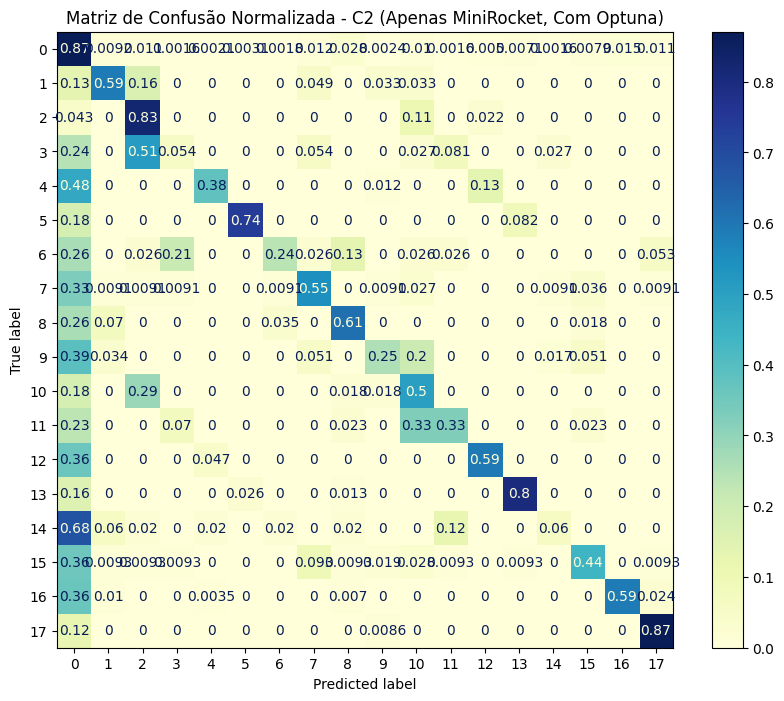

50590

In [10]:
# ==========================================
# CENÁRIO 2: Apenas MiniRocket, Com Optuna
# ==========================================
print("\n>>> CENÁRIO 2: Apenas MiniRocket, Com Optuna")
import warnings
import scipy
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=scipy.linalg.LinAlgWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ESTRATÉGIA 1: Usar apenas 20% dos dados para a busca do Optuna (Salva CPU e RAM)
n_samples = int(X_train_mr_scaled.shape[0] * 0.2)
X_train_sub = X_train_mr_scaled[:n_samples]
y_train_sub = y_train[:n_samples]

def obj_c2(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 1e4, log=True)

    # ESTRATÉGIA 2: Solvers que não duplicam memória internamente
    solver = trial.suggest_categorical('solver', ["auto", "lsqr"])

    clf = RidgeClassifier(alpha=alpha, solver=solver, class_weight='balanced')
    clf.fit(X_train_sub, y_train_sub) # Treinando na amostra!
    return f1_score(y_val, clf.predict(X_val_mr_scaled), average='macro')

study_c2 = optuna.create_study(direction='maximize')
study_c2.optimize(obj_c2, n_trials=15)

print(f"Melhores parâmetros C2: {study_c2.best_params}")
# Treinamento FINAL usa 100% dos dados
clf2 = RidgeClassifier(alpha=study_c2.best_params['alpha'], solver=study_c2.best_params['solver'], class_weight='balanced')
clf2.fit(X_train_mr_scaled, y_train)
avaliar("C2 (Apenas MiniRocket, Com Optuna)", clf2, X_val_mr_scaled, y_val, X_test_mr_scaled, y_test)

# ESTRATÉGIA 3: Faxina de RAM - Excluir matrizes antigas antes de rodar os cenários 3 e 4
del X_train_mr_scaled, X_val_mr_scaled, X_test_mr_scaled
import gc
gc.collect()


>>> CENÁRIO 3: MiniRocket + Features Estatísticas, Sem Optuna

AVALIANDO: C3 (MiniRocket + Stats, Sem Optuna)
F1-Macro Validação: 0.5243
F1-Macro Teste:     0.5918
Acurácia Teste:     0.8063

--- Relatório Detalhado (Teste) ---
              precision    recall  f1-score   support

           0       0.94      0.85      0.89      3815
           1       0.40      0.82      0.54        61
           2       0.56      0.85      0.67        46
           3       0.51      0.65      0.57        37
           4       0.53      0.66      0.59        82
           5       0.70      0.85      0.77        73
           6       0.38      0.95      0.55        38
           7       0.46      0.77      0.58       110
           8       0.31      0.67      0.42        57
           9       0.41      0.63      0.49        59
          10       0.52      0.77      0.62        56
          11       0.56      0.53      0.55        43
          12       0.81      0.53      0.64        86
          13  

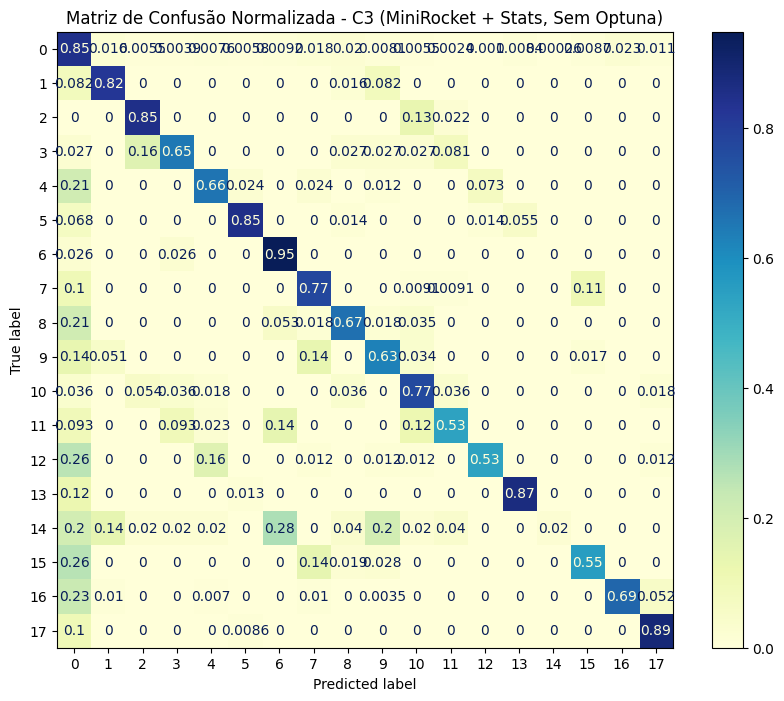

In [13]:
# ==========================================
# CENÁRIO 3: MiniRocket + Features Estatísticas, Sem Optuna
# ==========================================
print("\n>>> CENÁRIO 3: MiniRocket + Features Estatísticas, Sem Optuna")
clf3 = RidgeClassifierCV(alphas=np.logspace(-2, 4, 10), class_weight='balanced')
clf3.fit(X_train_fe_scaled, y_train)
best_alpha_3 = clf3.alpha_

clf3_f = RidgeClassifier(alpha=best_alpha_3, class_weight='balanced')
clf3_f.fit(X_train_fe_scaled, y_train)
avaliar("C3 (MiniRocket + Stats, Sem Optuna)", clf3_f, X_val_fe_scaled, y_val, X_test_fe_scaled, y_test)


>>> CENÁRIO 4: MiniRocket + Features Estatísticas, Com Optuna
Melhores parâmetros C4: {'alpha': 6416.327386508955, 'solver': 'auto'}

AVALIANDO: C4 (MiniRocket + Stats, Com Optuna)
F1-Macro Validação: 0.5069
F1-Macro Teste:     0.5883
Acurácia Teste:     0.7828

--- Relatório Detalhado (Teste) ---
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      3815
           1       0.33      0.85      0.48        61
           2       0.50      0.85      0.63        46
           3       0.46      0.68      0.55        37
           4       0.55      0.70      0.62        82
           5       0.67      0.86      0.75        73
           6       0.39      0.95      0.55        38
           7       0.42      0.79      0.55       110
           8       0.24      0.72      0.36        57
           9       0.41      0.66      0.51        59
          10       0.51      0.79      0.62        56
          11       0.59      0.53      0.56        

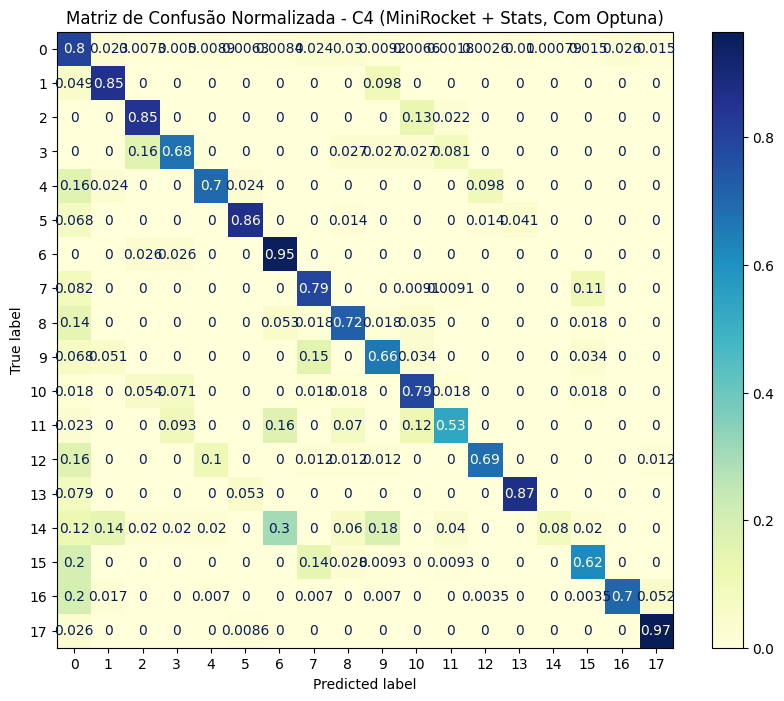

In [14]:
# ==========================================
# CENÁRIO 4: MiniRocket + Features Estatísticas, Com Optuna
# ==========================================
print("\n>>> CENÁRIO 4: MiniRocket + Features Estatísticas, Com Optuna")

# Amostragem de 20% para a matriz expandida
n_samples_fe = int(X_train_fe_scaled.shape[0] * 0.2)
X_train_fe_sub = X_train_fe_scaled[:n_samples_fe]
y_train_fe_sub = y_train[:n_samples_fe]

def obj_c4(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 1e4, log=True)
    solver = trial.suggest_categorical('solver', ["auto", "lsqr"])

    clf = RidgeClassifier(alpha=alpha, solver=solver, class_weight='balanced')
    clf.fit(X_train_fe_sub, y_train_fe_sub) # Treinando na amostra!
    return f1_score(y_val, clf.predict(X_val_fe_scaled), average='macro')

study_c4 = optuna.create_study(direction='maximize')
study_c4.optimize(obj_c4, n_trials=15)

print(f"Melhores parâmetros C4: {study_c4.best_params}")
clf4 = RidgeClassifier(alpha=study_c4.best_params['alpha'], solver=study_c4.best_params['solver'], class_weight='balanced')
clf4.fit(X_train_fe_scaled, y_train)
avaliar("C4 (MiniRocket + Stats, Com Optuna)", clf4, X_val_fe_scaled, y_val, X_test_fe_scaled, y_test)

In [15]:
# ==========================================
# RESUMO FINAL
# ==========================================
print("\n============================================================")
for c, res in resultados.items():
    print(f"{c}: F1-Macro = {res['F1-Macro']:.4f} | Acc = {res['Acurácia']:.4f}")


C1 (Apenas MiniRocket, Sem Optuna): F1-Macro = 0.4527 | Acc = 0.7711
C2 (Apenas MiniRocket, Com Optuna): F1-Macro = 0.4800 | Acc = 0.7828
C3 (MiniRocket + Stats, Sem Optuna): F1-Macro = 0.5918 | Acc = 0.8063
C4 (MiniRocket + Stats, Com Optuna): F1-Macro = 0.5883 | Acc = 0.7828
